In [1]:
import sys, os, time, math, random
import multiprocessing
import numpy as np
import numba
from numba import njit,prange
from joblib import Parallel, delayed

In [2]:
#Base
# the algorithm was taken from https://pythonmania.org/python-program-for-sieve-of-eratosthenes/
def sieve_of_eratosthenes(n):
    primes = [True] * (n+1)
    primes[0] = primes[1] = False

    p = 2
    while p * p <= n:
        if primes[p]:
            for i in range(p * p, n+1, p):
                primes[i] = False
        p += 1

    return [i for i, prime in enumerate(primes) if prime]


In [3]:
#Numpy
def sieve_of_eratosthenes_np(n):
    primes = np.ones(n+1,dtype=bool)
    primes[0] = primes[1] = False
    

    p = 2
    while p * p <= n:
        if primes[p]:
            primes[p * p::p] = False
        p += 1

    return [i for i, prime in enumerate(primes) if prime]

In [4]:
#Numba
@njit(nogil=True, parallel=True)
def sieve_of_eratosthenes_numba(n):
    primes = np.ones(n+1,dtype=np.uint8)#Numba doesn't support boolean values
    primes[0] = primes[1] = 0

    p = 2
    while p * p <= n:
        if primes[p]:
            primes[p * p::p] = 0
        p += 1

    return [i for i, prime in enumerate(primes) if prime]

In [5]:
%load_ext Cython

In [6]:
%%cython --compile-args=-fopenmp --link-args=-fopenmp

import numpy as np
cimport numpy as cnp

def sieve_of_eratosthenes_cython(int n):
    cdef cnp.ndarray[cnp.uint8_t, ndim=1] primes = np.ones(n+1, dtype=np.uint8)
    cdef int p = 2

    primes[0] = 0
    primes[1] = 0
    

    while p * p <= n:
        if primes[p]:
            primes[p * p::p] = 0
        p += 1
    return np.where(primes)[0]

In [7]:
#Joblib

def sieve(lim): # find all prime numbers up to sqrt(n), i.e. the base prime numbers
    primes = [True] * (lim + 1)
    primes[0] = primes[1] = False

    for i in range(2,int(math.sqrt(lim)) + 1):
        if primes[i]:
            for j in range(i*i, lim + 1,i):
                primes[j] = False
    return [i for i, prime in enumerate(primes) if prime]

def chunk_sieve(start,end,base):#find all prime numbers from sqrt(n) to n (by sieving off the products of the base prime numbers)
    chunk = [True] * (end - start)

    for p in base:
        first = max(p * p, ((start + p -1) // p) * p)
        for i in range(first,end,p):
            chunk[i - start] = False
    return [i + start for i, prime in enumerate(chunk) if prime and i + start >= 2]

def sieve_of_eratosthenes_joblib(n, n_jobs):
    lim = int(math.sqrt(n))
    base = sieve(lim)

    chunk_size = (n - lim) // n_jobs + 1
    chunks = [
        (start, min(start + chunk_size,n+1)) for start in range(lim + 1,n + 1, chunk_size)
    ]
    
    chunk_out = Parallel(n_jobs=n_jobs)(
        delayed(chunk_sieve)(start,end,base) for start, end in chunks
    )
    combined_primes = base[:]
    for p in chunk_out:
        combined_primes.extend(p)
    return combined_primes
    
    
    

In [8]:
def sieve(lim): # find all prime numbers up to sqrt(n), i.e. the base prime numbers
    primes = [True] * (lim + 1)
    primes[0] = primes[1] = False

    for i in range(2,int(math.sqrt(lim)) + 1):
        if primes[i]:
            for j in range(i*i, lim + 1,i):
                primes[j] = False
    return [i for i, prime in enumerate(primes) if prime]

def chunk_sieve(start,end,base):#find all prime numbers from sqrt(n) to n (by sieving off the products of the base prime numbers)
    chunk = [True] * (end - start)

    for p in base:
        first = max(p * p, ((start + p -1) // p) * p)
        for i in range(first,end,p):
            chunk[i - start] = False
    return [i + start for i, prime in enumerate(chunk) if prime and i + start >= 2]

def sieve_of_eratosthenes_multip(n, n_jobs):
    lim = int(math.sqrt(n))
    base = sieve(lim)

    chunk_size = (n - lim) // n_jobs + 1
    chunks = [
        (start, min(start + chunk_size,n+1)) for start in range(lim + 1,n + 1, chunk_size)
    ]
    with multiprocessing.Pool(processes=n_jobs) as pool:
        chunk_out = pool.starmap(chunk_sieve,[(start,end,base) for start, end in chunks])
    combined_primes = base[:]
    for p in chunk_out:
        combined_primes.extend(p)
    return combined_primes

In [9]:
numba.set_num_threads(4)

73.7 μs ± 6.36 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
75.4 μs ± 20.7 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
15.2 μs ± 498 ns per loop (mean ± std. dev. of 7 runs, 20 loops each)
The slowest run took 3048.02 times longer than the fastest. This could mean that an intermediate result is being cached.
5.52 ms ± 13.5 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
The slowest run took 4.59 times longer than the fastest. This could mean that an intermediate result is being cached.
17.1 ms ± 13.9 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
79.5 ms ± 876 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
841 μs ± 49.4 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
605 μs ± 13.1 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
58 μs ± 16.6 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
61.5 μs ± 32.4 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
11.3 ms ± 230 μs per loop (mean ± std. dev. of 7 runs, 20

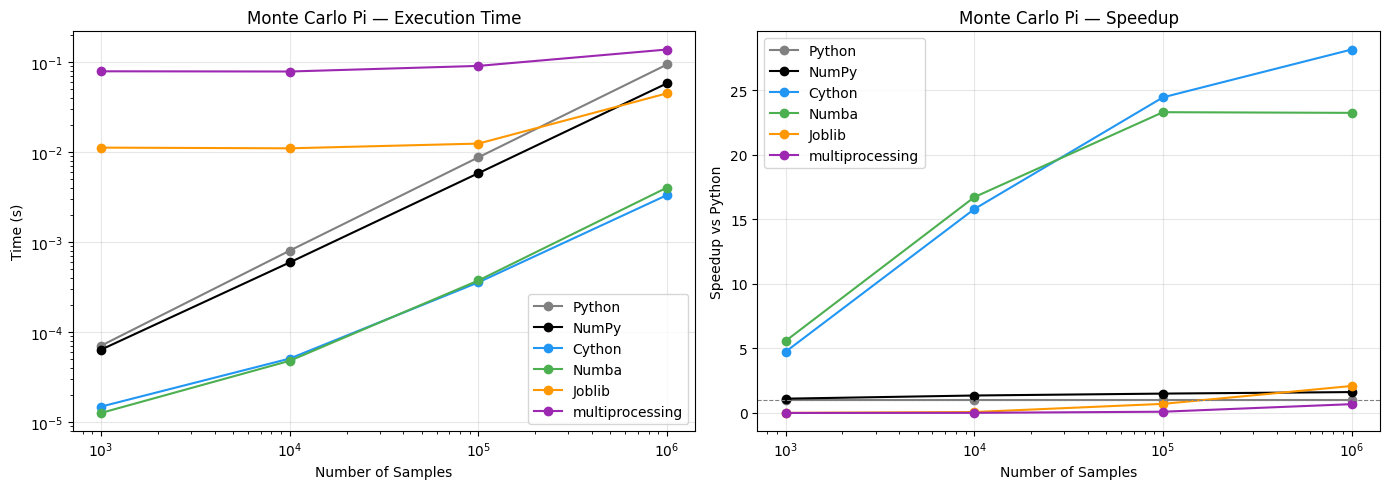

In [10]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [1000, 10000,100000,1000000]
libraries = ['Python', 'NumPy', 'Cython', 'Numba', 'Joblib', 'multiprocessing']
results = {lib: [] for lib in libraries}

for n in sizes:
    t = %timeit -o -n 20 sieve_of_eratosthenes(n)
    results['Python'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_np(n)
    results['NumPy'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_cython(n)
    results['Cython'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_numba(n)
    results['Numba'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_joblib(n, 4)
    results['Joblib'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_multip(n, 4)
    results['multiprocessing'].append(t.best)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['gray', 'black', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Left: execution time
for lib, color in zip(libraries, colors):
    axes[0].loglog(sizes, results[lib], marker='o', label=lib, color=color)
axes[0].set_xlabel('Number of Samples')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Sieve of Eratosthenes — Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: speedup vs Python
baseline = results['Python']
for lib, color in zip(libraries, colors):
    speedup = [baseline[i] / results[lib][i] for i in range(len(sizes))]
    axes[1].semilogx(sizes, speedup, marker='o', label=lib, color=color)
axes[1].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_xlabel('Number of Samples')
axes[1].set_ylabel('Speedup vs Python')
axes[1].set_title('Sieve of Eratosthenes — Speedup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sieve_results_4.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
numba.set_num_threads(8)

83.7 μs ± 7.82 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
77.4 μs ± 4.64 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
22.6 μs ± 13.1 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
The slowest run took 7.61 times longer than the fastest. This could mean that an intermediate result is being cached.
26 μs ± 30.4 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
The slowest run took 5.47 times longer than the fastest. This could mean that an intermediate result is being cached.
18.7 ms ± 17.3 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
149 ms ± 2 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
822 μs ± 49.5 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
587 μs ± 14.9 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
61.3 μs ± 15.8 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
64.7 μs ± 31.1 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
11.6 ms ± 278 μs per loop (mean ± std. dev. of 7 runs, 20 loop

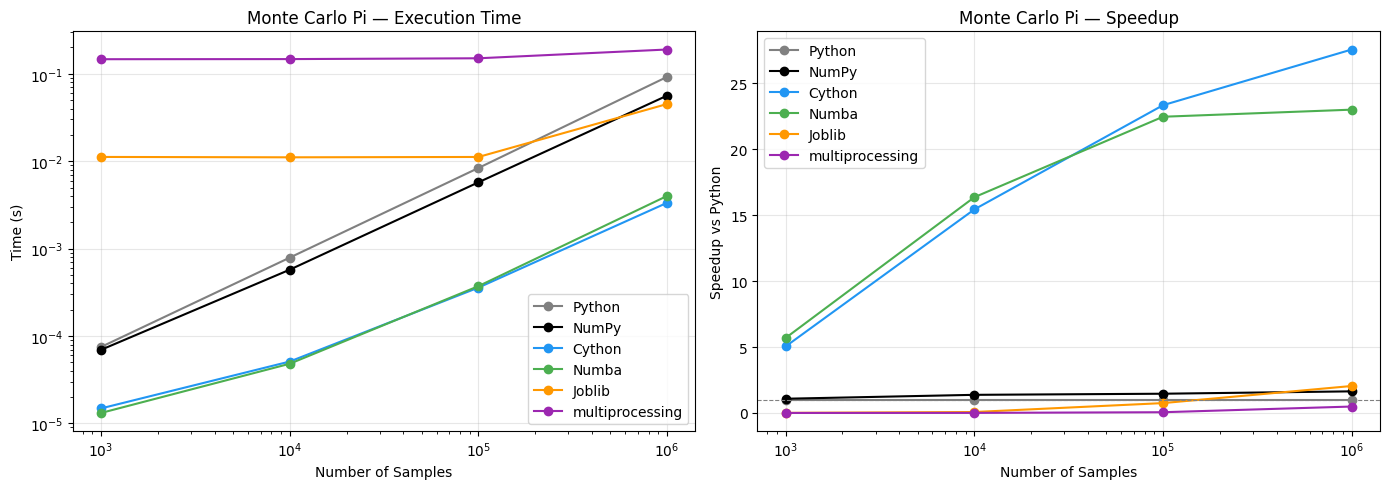

In [12]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [1000, 10000,100000,1000000]
libraries = ['Python', 'NumPy', 'Cython', 'Numba', 'Joblib', 'multiprocessing']
results = {lib: [] for lib in libraries}

for n in sizes:
    t = %timeit -o -n 20 sieve_of_eratosthenes(n)
    results['Python'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_np(n)
    results['NumPy'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_cython(n)
    results['Cython'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_numba(n)
    results['Numba'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_joblib(n, 8)
    results['Joblib'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_multip(n, 8)
    results['multiprocessing'].append(t.best)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['gray', 'black', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Left: execution time
for lib, color in zip(libraries, colors):
    axes[0].loglog(sizes, results[lib], marker='o', label=lib, color=color)
axes[0].set_xlabel('Number of Samples')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Sieve of Eratosthenes — Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: speedup vs Python
baseline = results['Python']
for lib, color in zip(libraries, colors):
    speedup = [baseline[i] / results[lib][i] for i in range(len(sizes))]
    axes[1].semilogx(sizes, speedup, marker='o', label=lib, color=color)
axes[1].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_xlabel('Number of Samples')
axes[1].set_ylabel('Speedup vs Python')
axes[1].set_title('Sieve of Eratosthenes — Speedup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sieve_results_8.png', dpi=150, bbox_inches='tight')
plt.show()

76.7 μs ± 5.79 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
79.9 μs ± 1.84 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
19 μs ± 8.24 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
The slowest run took 5.57 times longer than the fastest. This could mean that an intermediate result is being cached.
40.8 μs ± 38 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
14.9 ms ± 4.18 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
305 ms ± 3.1 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
814 μs ± 28.4 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
607 μs ± 7.06 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
61 μs ± 15.7 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
65 μs ± 34 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
11.5 ms ± 245 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
302 ms ± 2.25 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
8.58 ms ± 96 μs per loop (mean ± std. dev. of 

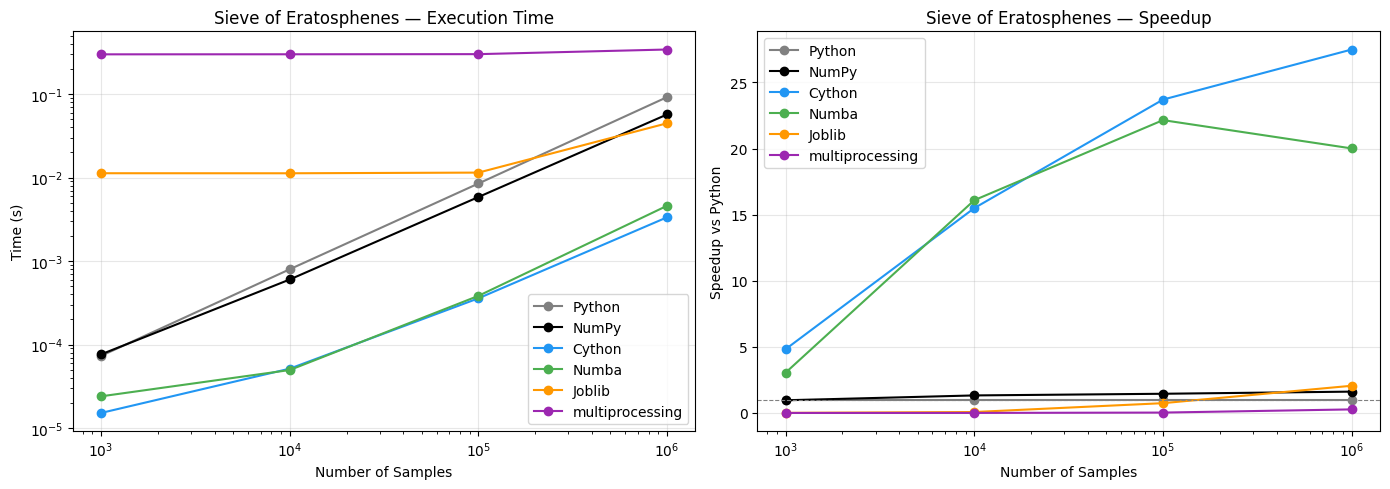

In [13]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [1000, 10000,100000,1000000]
libraries = ['Python', 'NumPy', 'Cython', 'Numba', 'Joblib', 'multiprocessing']
results = {lib: [] for lib in libraries}

for n in sizes:
    t = %timeit -o -n 20 sieve_of_eratosthenes(n)
    results['Python'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_np(n)
    results['NumPy'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_cython(n)
    results['Cython'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_numba(n)
    results['Numba'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_joblib(n, 16)
    results['Joblib'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_multip(n, 16)
    results['multiprocessing'].append(t.best)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['gray', 'black', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Left: execution time
for lib, color in zip(libraries, colors):
    axes[0].loglog(sizes, results[lib], marker='o', label=lib, color=color)
axes[0].set_xlabel('Number of Samples')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Sieve of Eratosphenes — Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: speedup vs Python
baseline = results['Python']
for lib, color in zip(libraries, colors):
    speedup = [baseline[i] / results[lib][i] for i in range(len(sizes))]
    axes[1].semilogx(sizes, speedup, marker='o', label=lib, color=color)
axes[1].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_xlabel('Number of Samples')
axes[1].set_ylabel('Speedup vs Python')
axes[1].set_title('Sieve of Eratosphenes — Speedup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sieve_results_16.png', dpi=150, bbox_inches='tight')
plt.show()